# OASIS Project - data prep

Same idea as `01_data_preparation.ipynb` but for the proper OASIS data instead of the Kaggle
one. Doesn't train anything, just sorts out the data.

Run it top to bottom. Everything gets saved into `prepped_data_oasis/`.

The reason for bothering when we already have the Kaggle set is that this one comes with the
actual clinical scores, real patient IDs, and scans that have already been lined up to a
standard brain template. That last bit means slice 70 is the same part of the brain in every
person, which is what we need if we want to check later whether a Grad-CAM heatmap is looking
at the hippocampus or not.

## Setup

In [1]:
import os
import re
import json
import random
import tarfile
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

# folder with the tar files and the spreadsheet in it
oasis_folder = "Data"

# where the scans we pull out of the tars go, and where the results go
scans_folder = "extracted_scans"
output_folder = "prepped_data_oasis"
os.makedirs(scans_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

classes = ["Non_Demented", "Very_Mild_Demented", "Mild_Demented"]

# CDR is the clinical score - 0 is healthy, 0.5 very mild, 1 mild
cdr_to_class = {0.0: "Non_Demented", 0.5: "Very_Mild_Demented", 1.0: "Mild_Demented"}

# which slices to keep. brain is in slices 13-151 but we only want the middle chunk
# where the hippocampus is
slice_numbers = list(range(56, 96, 2))

random_seed = 123

## Getting the labels

The spreadsheet has a row per scan with the CDR score and a few other things like age, sex
and MMSE.

Loads of people have no CDR at all. Those are the younger subjects who never got assessed, so
we can't use them - no score isn't the same as healthy. There's also 2 people with CDR 2
(moderate) which is nowhere near enough to train on, so they go too.

In [2]:
excel_file = [f for f in os.listdir(oasis_folder)
              if f.startswith("oasis_cross-sectional-") and "reliability" not in f][0]
clinical = pd.read_excel(os.path.join(oasis_folder, excel_file))

print("rows in the spreadsheet:", len(clinical))
print()
print("CDR scores:")
print(clinical["CDR"].value_counts(dropna=False).sort_index().to_string())

rows in the spreadsheet: 436

CDR scores:
CDR
0.0    135
0.5     70
1.0     28
2.0      2
NaN    201


In [3]:
# ID looks like OAS1_0001_MR1, the patient bit is the first two chunks
clinical["patient_id"] = clinical["ID"].str.extract(r"(OAS1_\d+)")
clinical["session_id"] = clinical["ID"]

labels = clinical[clinical["CDR"].isin(cdr_to_class.keys())].copy()
labels["class_name"] = labels["CDR"].map(cdr_to_class)
labels["label"] = labels["class_name"].map(lambda c: classes.index(c))

print("people we can use:", len(labels))
print()
for class_name in classes:
    subset = labels[labels["class_name"] == class_name]
    print(class_name + ":", len(subset), "people, average age", round(subset["Age"].mean(), 1))

people we can use: 233

Non_Demented: 135 people, average age 69.1
Very_Mild_Demented: 70 people, average age 76.2
Mild_Demented: 28 people, average age 77.8


Worth noticing the average ages there. The classes are about 9 years apart, so a model could
get a decent score just by spotting old brains rather than sick ones. We keep age in the
output so we can check for that later.

## Pulling the scans out

Each person's folder in the tar has a lot in it - four raw scans, processed versions, tissue
segmentations, preview gifs. We only want one file each:

`PROCESSED/MPRAGE/T88_111/..._t88_masked_gfc.img`

That's the four scans averaged together, brightness corrected, skull removed and lined up to
the template. About 13MB each so roughly 3GB for everyone, instead of the 50GB it'd be if we
pulled out everything.

The tars are 4GB each so this cell is slow the first time. It skips anything already pulled
out so running it again is quick.

In [4]:
wanted_patients = set(labels["patient_id"])

for disc in range(1, 13):
    tar_path = os.path.join(oasis_folder, "oasis_cross-sectional_disc%d.tar" % disc)
    if not os.path.exists(tar_path):
        print("disc", disc, "- no tar found, skipping")
        continue

    pulled = 0
    with tarfile.open(tar_path) as tar:
        for member in tar:
            if not member.name.endswith((".img", ".hdr")):
                continue
            if "T88_111" not in member.name or "masked_gfc" not in member.name:
                continue
            if "fseg" in member.name:
                continue

            match = re.search(r"(OAS1_\d+_MR\d+)", member.name)
            if match is None:
                continue

            session_id = match.group(1)
            patient_id = session_id.rsplit("_", 1)[0]
            if patient_id not in wanted_patients:
                continue

            extension = os.path.splitext(member.name)[1]
            target = os.path.join(scans_folder, session_id + extension)
            if os.path.exists(target):
                continue

            with open(target, "wb") as f:
                f.write(tar.extractfile(member).read())
            if extension == ".img":
                pulled += 1

    print("disc", disc, "-", pulled, "scans pulled out")

scans = sorted(f[:-4] for f in os.listdir(scans_folder) if f.endswith(".img"))
print()
print("scans on disk:", len(scans))

disc 1 - 0 scans pulled out


disc 2 - 0 scans pulled out


disc 3 - 0 scans pulled out


disc 4 - 0 scans pulled out


disc 5 - 0 scans pulled out


...

disc 7 - 0 scans pulled out


disc 8 - 0 scans pulled out


disc 9 - 0 scans pulled out
disc 10 - 0 scans pulled out


disc 11 - 0 scans pulled out


disc 12 - 0 scans pulled out

scans on disk: 233


## Checking a scan

Quick look at one before doing the lot.

In [5]:
example_session = scans[0]
example = nib.load(os.path.join(scans_folder, example_session + ".hdr"))
volume = np.squeeze(example.get_fdata())

print("session:", example_session)
print("shape:", volume.shape)
print("voxel size:", example.header.get_zooms()[:3], "mm")
print("orientation:", nib.aff2axcodes(example.affine))
print("brightness range:", float(volume.min()), "to", float(volume.max()))

session: OAS1_0001_MR1
shape: (176, 208, 176)
voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
orientation: ('L', 'A', 'S')
brightness range: 0.0 to 3126.0


The third axis goes from the bottom of the head to the top, so that's the one we slice along
to get the normal top-down view. Let's plot the slices we're keeping and check they look
sensible.

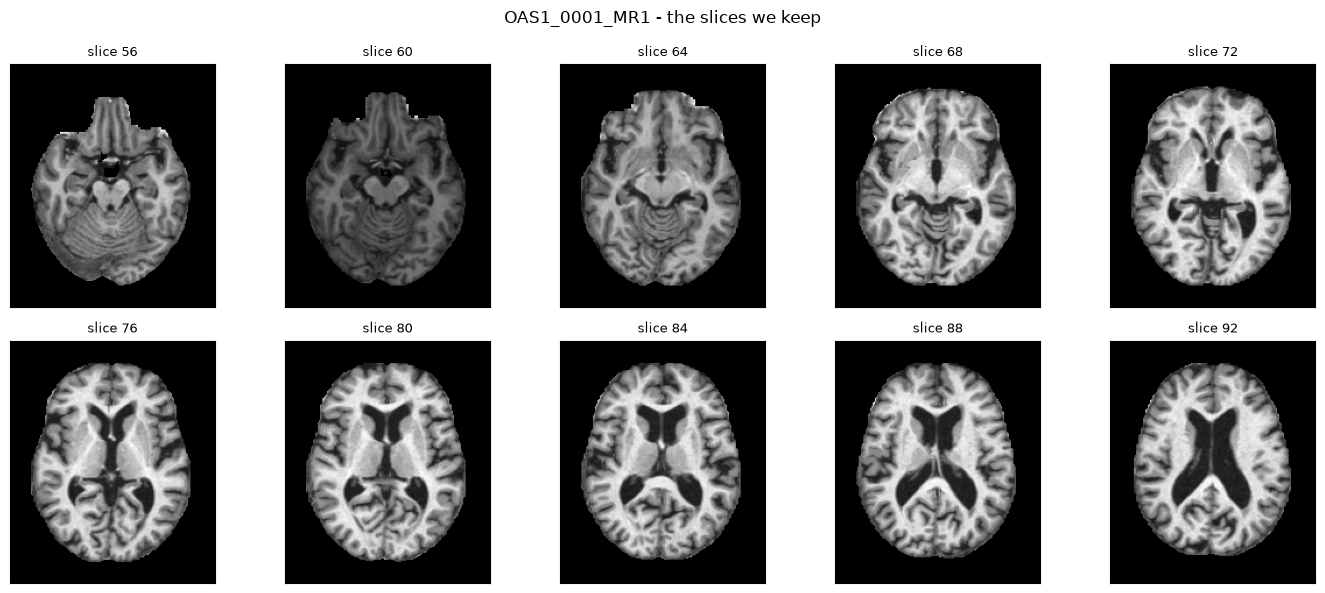

In [6]:
def get_slice(volume, k):
    # transpose and flip so the front of the head ends up at the top of the picture
    return np.flipud(volume[:, :, k].T)


figure, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, k in zip(axes.flatten(), slice_numbers[::2]):
    ax.imshow(get_slice(volume, k), cmap="gray")
    ax.set_title("slice " + str(k), fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
figure.suptitle(example_session + " - the slices we keep")
plt.tight_layout()
plt.show()

Skull's already gone which saves us a job, and the brain fills the frame the same way in every
scan because they've all been lined up to the same template.

## Making the slices

One row per slice. Each scan gets scaled to 0-255 using its own brightest voxel, because MRI
doesn't come on a fixed brightness scale like a photo does - two scans of the same person can
have totally different numbers in them.

In [7]:
rows = []
all_slices = []

label_of_session = labels.set_index("session_id")

for session_id in scans:
    if session_id not in label_of_session.index:
        continue
    info = label_of_session.loc[session_id]

    volume = np.squeeze(nib.load(os.path.join(scans_folder, session_id + ".hdr")).get_fdata())

    # scale this scan on its own
    top = np.percentile(volume[volume > 0], 99.5)
    scaled = np.clip(volume / top, 0, 1)

    for k in slice_numbers:
        image = get_slice(scaled, k)
        all_slices.append((image * 255).astype(np.uint8))

        rows.append({
            "session_id": session_id,
            "patient_id": info["patient_id"],
            "slice_number": k,
            "cdr": info["CDR"],
            "class_name": info["class_name"],
            "label": info["label"],
            "age": info["Age"],
            "sex": info["M/F"],
            "mmse": info["MMSE"],
            "nwbv": info["nWBV"],
            "brain_fraction": float((image > 0).mean()),
        })

data = pd.DataFrame(rows)
all_slices = np.stack(all_slices)

print("slices:", len(data))
print("people:", data["patient_id"].nunique())
print("image size:", all_slices.shape[1:])
print()
print("slices per class:")
for class_name in classes:
    print(class_name + ":", len(data[data["class_name"] == class_name]))

slices: 4660
people: 233
image size: (208, 176)

slices per class:
Non_Demented: 2700
Very_Mild_Demented: 1400
Mild_Demented: 560


## Splitting by patient

Same as the other notebook. 70/15/15 done per class, shuffling the people rather than the
slices so all of one person's slices end up on the same side.

Also making 5 CV folds the same way.

In [8]:
random.seed(random_seed)

train_patients = []
val_patients = []
test_patients = []

for class_name in classes:
    patients = sorted(set(data[data["class_name"] == class_name]["patient_id"]))
    random.shuffle(patients)

    n_train = round(0.70 * len(patients))
    n_val = round(0.15 * len(patients))

    train_patients += patients[:n_train]
    val_patients += patients[n_train:n_train + n_val]
    test_patients += patients[n_train + n_val:]

splits = []
for patient_id in data["patient_id"]:
    if patient_id in train_patients:
        splits.append("train")
    elif patient_id in val_patients:
        splits.append("val")
    else:
        splits.append("test")

data["split"] = splits

print("people: train", len(train_patients), "/ val", len(val_patients), "/ test", len(test_patients))
print("slices:", data["split"].value_counts().to_dict())
print()
print("people per class per split:")
print(data.groupby(["class_name", "split"])["patient_id"].nunique().unstack().to_string())

people: train 163 / val 34 / test 36
slices: {'train': 3260, 'test': 720, 'val': 680}

people per class per split:
split               test  train  val
class_name                          
Mild_Demented          4     20    4
Non_Demented          21     94   20
Very_Mild_Demented    11     49   10


In [9]:
# 5 CV folds, also by patient
random.seed(random_seed)
fold_of_patient = {}

for class_name in classes:
    patients = sorted(set(data[data["class_name"] == class_name]["patient_id"]))
    random.shuffle(patients)
    for i in range(len(patients)):
        fold_of_patient[patients[i]] = i % 5

data["cv_fold"] = [fold_of_patient[p] for p in data["patient_id"]]

print("people per fold:")
for fold in range(5):
    print("fold", fold, "-", data[data["cv_fold"] == fold]["patient_id"].nunique())

people per fold:
fold 0 - 47
fold 1 - 47
fold 2 - 47
fold 3 - 46
fold 4 - 46


In [10]:
# class weights for the loss function counted by patient
train_data = data[data["split"] == "train"]
total_patients = train_data["patient_id"].nunique()

class_weights = []
for class_name in classes:
    n = train_data[train_data["class_name"] == class_name]["patient_id"].nunique()
    class_weights.append(round(total_patients / (len(classes) * n), 4))

print("class weights:", class_weights)

class weights: [0.578, 1.1088, 2.7167]


## Saving

In [11]:
data.to_csv(os.path.join(output_folder, "data_final.csv"), index=False)
np.savez_compressed(os.path.join(output_folder, "slices.npz"), slices=all_slices)

dataset_info = {
    "source": "OASIS-1 cross-sectional, T88_111 masked_gfc scans",
    "number_of_slices": len(data),
    "number_of_patients": int(data["patient_id"].nunique()),
    "image_size": list(all_slices.shape[1:]),
    "slice_numbers": slice_numbers,
    "classes": classes,
    "class_weights": class_weights,
    "slices_per_class": {c: int((data["class_name"] == c).sum()) for c in classes},
    "patients_per_class": {c: int(data[data["class_name"] == c]["patient_id"].nunique())
                           for c in classes},
    "patients_per_split": {s: int(data[data["split"] == s]["patient_id"].nunique())
                           for s in ["train", "val", "test"]},
    "random_seed": random_seed,
}

with open(os.path.join(output_folder, "dataset_info.json"), "w") as f:
    json.dump(dataset_info, f, indent=2)

print("saved into " + output_folder + "/:")
print("data_final.csv -", len(data), "rows")
print("slices.npz -", all_slices.shape)
print("dataset_info.json")

saved into prepped_data_oasis/:
data_final.csv - 4660 rows
slices.npz - (4660, 208, 176)
dataset_info.json


## Next steps

Someone else from the group should follow on from this by doing feature engineering and
augmentation.

## Using it

Copy this into your notebook, you don't need to re-run the prep. The images are in the npz
this time rather than loose files, so row `i` of the csv is `slices[i]`.

```python
import numpy as np
import pandas as pd

data_final = pd.read_csv("prepped_data_oasis/data_final.csv")
slices = np.load("prepped_data_oasis/slices.npz")["slices"]

train = data_final[data_final["split"] == "train"]
val   = data_final[data_final["split"] == "val"]
test  = data_final[data_final["split"] == "test"]

x_train = slices[train.index] / 255.0
y_train = train["label"].values
```

Brain mask for the XAI side is just `slices[i] > 0` since the skull is already off.